# Lending Club Loan Default Risk Analysis

### Dataset: Lending Club Loan Dataset (Preprocessed)
### Domain: Fintech / Credit Risk Analytics

### Business Problem

Digital lending platforms issue loans to borrowers with diverse financial profiles. While these loans generate revenue through interest payments, borrower defaults create financial losses and increase credit risk for the lending company.

To maintain a healthy and profitable loan portfolio, lenders need to understand which borrower characteristics and loan attributes are associated with higher default risk. Identifying these patterns can help lenders improve credit decisions and reduce potential financial losses.

### Project Objective

The objective of this project is to analyze historical lending data to identify key borrower and loan characteristics that influence loan default risk.

Through data analysis and statistical exploration, this project aims to detect high-risk borrower segments and understand how financial attributes such as income, debt-to-income ratio, interest rate, and employment history affect loan repayment behavior.

### Key Business Questions

1️. What is the overall default rate in the loan portfolio?

2️. How does Debt-to-Income (DTI) influence the likelihood of loan default?

3️. Does borrower income significantly impact loan repayment behavior?

4️. Which loan purposes show the highest default rates?

5️. Do loans with higher interest rates experience more defaults?

6️. Does employment length relate to repayment reliability?

7️. Which borrower segments contribute the most to portfolio risk?

###  Key Metrics

1. Total Loans
2. Default Loans
3. Default Rate
4. Average Loan Amount
5. Average Interest Rate
6. Average DTI

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy.stats import ttest_ind
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("C:/Users/user/Desktop/fintech/lending_club_loan_two.csv")
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [7]:
pd.set_option('display.max_columns', None)
df.head(2)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,Not Verified,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,Not Verified,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"


In [8]:
df.shape

(396030, 27)

In [6]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [11]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [12]:
df.isnull().sum().sort_values(ascending=False)

mort_acc                37795
emp_title               22927
emp_length              18301
title                    1756
pub_rec_bankruptcies      535
revol_util                276
loan_amnt                   0
dti                         0
application_type            0
initial_list_status         0
total_acc                   0
revol_bal                   0
pub_rec                     0
open_acc                    0
earliest_cr_line            0
purpose                     0
term                        0
loan_status                 0
issue_d                     0
verification_status         0
annual_inc                  0
home_ownership              0
sub_grade                   0
grade                       0
installment                 0
int_rate                    0
address                     0
dtype: int64

In [13]:
df.drop('emp_title',axis=1,inplace=True)

### The emp_title column contains highly unstructured job titles with thousands of unique values, making it unsuitable for meaningful aggregation or risk analysis.

In [14]:
df.drop('title',axis=1,inplace=True)

### The title column duplicates information already available in the purpose variable, therefore it was removed to avoid redundancy.

In [15]:
df['emp_length'].fillna('Unknown',inplace=True)

### Missing values in emp_length were replaced with "Unknown" to preserve observations while acknowledging unavailable employment history.

In [16]:
df['mort_acc'].fillna(df['mort_acc'].median(),inplace=True)

### Missing values in mort_acc were imputed using the median to preserve the distribution of mortgage account counts.

In [17]:
df['pub_rec_bankruptcies'].fillna(0,inplace=True)

### Missing values in pub_rec_bankruptcies were replaced with 0, assuming no recorded bankruptcy events.

In [18]:
df['revol_util'].fillna(df['revol_util'].median(),inplace=True)

### Missing values in revol_util were imputed using the median to maintain dataset consistency.

In [19]:
df.isnull().sum()

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0
dtype: int64

In [20]:
df = df[df['dti'] < 60]

Extreme DTI values (e.g., 9999) were removed to avoid distortion in risk analysis.

In [21]:
df['loan_status'].value_counts()

loan_status
Fully Paid     318341
Charged Off     77670
Name: count, dtype: int64

In [22]:
df['default_flag'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off' : 1
    
})

In [23]:
df['default_flag'].value_counts()

default_flag
0    318341
1     77670
Name: count, dtype: int64

In [25]:
df[['loan_status','default_flag']].head(5)

,loan_status,default_flag
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
3,Fully Paid,0
4,Charged Off,1


In [26]:
df['default_flag'].mean()*100

np.float64(19.613091555537597)

Assumptions:
Only borrower and loan application features were used. Post-loan variables were not considered to avoid data leakage. This ensures realistic credit risk analysis.

### The loan portfolio shows an overall default rate of approximately 19.6%, indicating that nearly one in five loans resulted in charge-offs.

## Exploratory Data Analysis (EDA)

This section analyzes borrower financial characteristics and loan attributes to identify patterns associated with loan default risk.

## Q1️. What is the overall default rate in the loan portfolio?

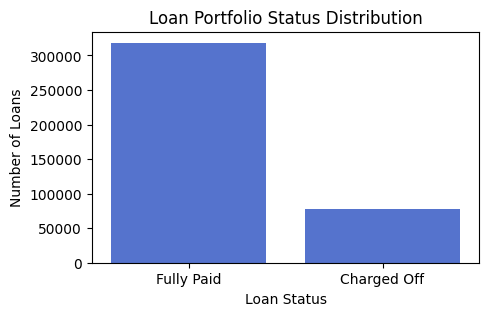

In [27]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='loan_status', color = "royalblue")
plt.title("Loan Portfolio Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (8,5)
plt.show()

**Figure:** Loan Portfolio Status Distribution

This chart shows the number of loans that were fully repaid versus those that were charged off.

### Insight:
The loan portfolio consists of approximately 318k fully repaid loans and 77k charged-off loans, resulting in a default rate of around 19.6%. This indicates that nearly one out of every five loans resulted in default, highlighting substantial credit risk within the portfolio

## Q2. How does Debt-to-Income (DTI) influence the likelihood of loan default?

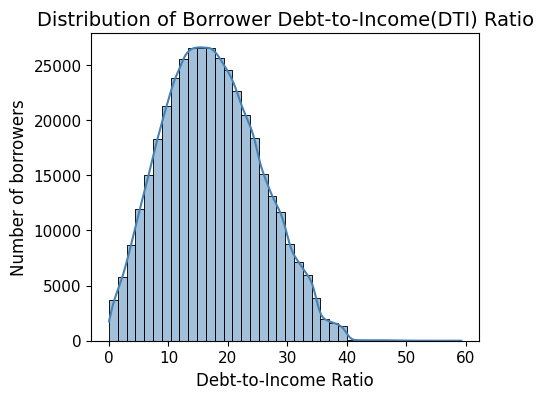

In [28]:
plt.figure(figsize=(5,4))
sns.histplot(df[df['dti']<60]['dti'], bins=40, kde= True, color = 'steelblue')
plt.title("Distribution of Borrower Debt-to-Income(DTI) Ratio")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of borrowers")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (8,5)
plt.show()

In [29]:
df['dti'].describe()

count    396011.000000
mean         17.346216
std           8.122951
min           0.000000
25%          11.280000
50%          16.900000
75%          22.980000
max          59.260000
Name: dti, dtype: float64

### The distribution of Debt-to-Income ratios shows that most borrowers maintain DTI levels between approximately 11% and 23%, indicating moderate debt obligations relative to income. A small number of extreme values, including 9999%, suggest potential outliers or data entry anomalies in the dataset.

In [30]:
df[df['dti']>60].shape

(0, 26)

In [31]:
df['dti_group'] = pd.cut(
    df['dti'],
    bins=[0,10,20,30,40,100],
    labels=['0-10','10-20','20-30','30-40','40+']
)

In [48]:
dti_default = df.groupby('dti_group')['default_flag'].mean()*100
dti_default

dti_group
0-10     13.721931
10-20    17.502359
20-30    23.650590
30-40    32.457961
40+      33.574007
Name: default_flag, dtype: float64

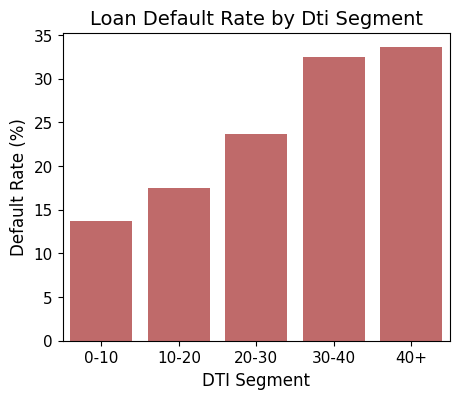

In [33]:
plt.figure(figsize=(5,4))
sns.barplot(x=dti_default.index, y=dti_default.values,color = "indianred")
plt.title("Loan Default Rate by Dti Segment")
plt.xlabel("DTI Segment")
plt.ylabel("Default Rate (%)")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (8,5)
plt.show()

### Insight:
Default rates increase sharply beyond DTI 30 (from ~17% to ~32%), making it a critical risk threshold. Default rates increase from approximately 13.7% for borrowers with DTI below 10 to over 32% for borrowers with DTI above 30, indicating that higher debt burdens strongly correlate with increased loan default probability.

### Q3. Does borrower income significantly impact loan repayment behavior?


In [34]:
df['annual_inc'].describe()

count    3.960110e+05
mean     7.420592e+04
std      6.163771e+04
min      4.000000e+03
25%      4.500000e+04
50%      6.400000e+04
75%      9.000000e+04
max      8.706582e+06
Name: annual_inc, dtype: float64

In [35]:
df['income_group']= pd.cut(
    df['annual_inc'],
    bins=[0,40000,80000,120000,200000,1000000],
    labels=['<40k','40k-80k','80k-120k','120k-200k','200k+']
)

In [47]:
income_default = df.groupby('income_group')['default_flag'].mean()*100
income_default

income_group
<40k         24.617896
40k-80k      20.323746
80k-120k     16.018131
120k-200k    14.316101
200k+        13.739459
Name: default_flag, dtype: float64

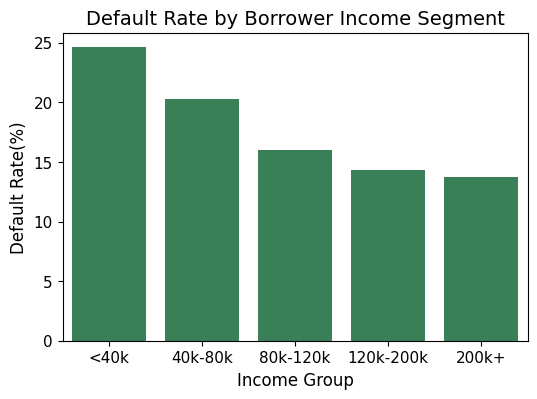

In [37]:
plt.figure(figsize=(6,4))
sns.barplot(x=income_default.index, y=income_default.values, color = "seagreen")
plt.title("Default Rate by Borrower Income Segment")
plt.xlabel("Income Group")
plt.ylabel("Default Rate(%)")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (8,5)
plt.show()

### Insight:
Borrowers with lower annual income show significantly higher default rates. Loans issued to borrowers earning below USD 40k exhibit a default rate of approximately 24.6%, while borrowers with income above USD 200k show a much lower default rate of around 13.7%, indicating that higher income levels are associated with improved repayment performance.

### Q4️. Which loan purposes show the highest default rates?


In [38]:
df['purpose'].value_counts()

purpose
debt_consolidation    234500
credit_card            83010
home_improvement       24030
other                  21182
major_purchase          8790
small_business          5701
car                     4697
medical                 4196
moving                  2854
vacation                2452
house                   2201
wedding                 1812
renewable_energy         329
educational              257
Name: count, dtype: int64

In [39]:
purpose_default = df.groupby('purpose')['default_flag'].mean()*100
purpose_default.sort_values(ascending=True)

purpose
wedding               12.086093
car                   13.476687
educational           16.342412
major_purchase        16.473265
credit_card           16.711240
home_improvement      17.007907
vacation              18.923328
house                 19.718310
debt_consolidation    20.742004
other                 21.216127
medical               21.711153
renewable_energy      23.404255
moving                23.475823
small_business        29.450974
Name: default_flag, dtype: float64

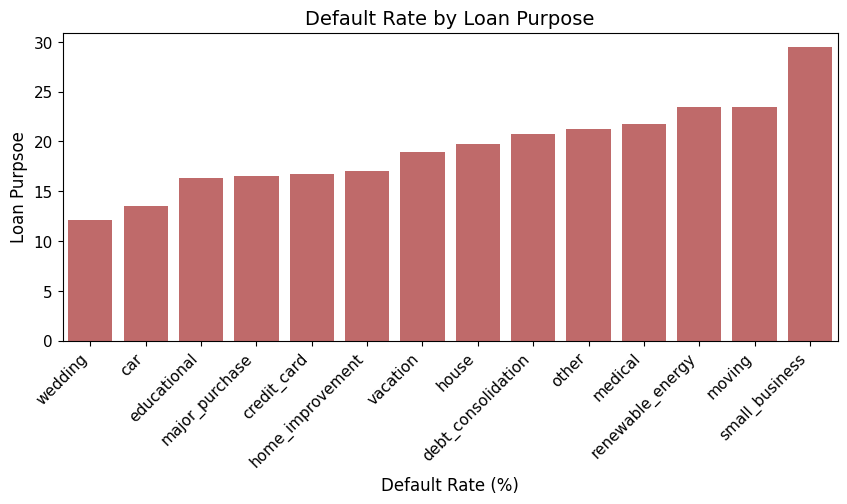

In [40]:
purpose_default = purpose_default.sort_values()
plt.figure(figsize=(10,4))
sns.barplot(x=purpose_default.index, y=purpose_default.values, color = "indianred")
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpsoe")
plt.xticks(rotation= 45, ha = 'right')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (8,5)
plt.show()

### Insight:
Default risk varies significantly across loan purposes. Small business loans exhibit the highest default rate at approximately 29.5%, while loans taken for weddings and car purchases show much lower default rates around 12–13%. This indicates that certain loan purposes carry substantially higher credit risk.

### Q5️. Do loans with higher interest rates experience more defaults?


In [41]:
df['int_rate'].describe()

count    396011.000000
mean         13.639334
std           4.472063
min           5.320000
25%          10.490000
50%          13.330000
75%          16.490000
max          30.990000
Name: int_rate, dtype: float64

In [42]:
df['rate_group']=pd.cut(
    df['int_rate'],
    bins=[0,8,12,16,20,30],
    labels=['0-8%','8-12%','12-16%','16-20%','20%+']
)

In [49]:
rate_default = df.groupby('rate_group')['default_flag'].mean()*100
rate_default

rate_group
0-8%       5.707279
8-12%     11.684562
12-16%    19.914257
16-20%    29.994424
20%+      39.147335
Name: default_flag, dtype: float64

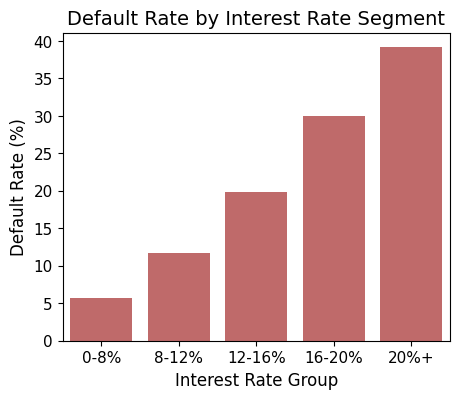

In [44]:
plt.figure(figsize=(5,4))
sns.barplot(x=rate_default.index, y=rate_default.values, color="indianred")
plt.title("Default Rate by Interest Rate Segment")
plt.xlabel("Interest Rate Group")
plt.ylabel("Default Rate (%)")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (8,5)
plt.show()

### Inisght
Default rates increase significantly as interest rates rise. Loans with interest rates below 8% show a default rate of approximately 5.7%, while loans with rates above 20% exhibit default rates exceeding 39%. This suggests that loans priced at higher interest rates are associated with substantially higher credit risk.

### Q6️. Does employment length relate to repayment reliability?

In [39]:
df['emp_length'].value_counts()

emp_length
10+ years    126041
2 years       35827
< 1 year      31725
3 years       31665
5 years       26495
1 year        25882
4 years       23952
6 years       20841
7 years       20819
8 years       19168
Unknown       18301
9 years       15314
Name: count, dtype: int64

In [40]:
emp_default = df.groupby('emp_length')['default_flag'].mean()*100
emp_default.sort_values()

emp_length
10+ years    18.418610
6 years      18.919438
5 years      19.218721
4 years      19.238477
2 years      19.326206
7 years      19.477400
3 years      19.523133
1 year       19.913453
8 years      19.976002
9 years      20.047016
< 1 year     20.687155
Unknown      27.528550
Name: default_flag, dtype: float64

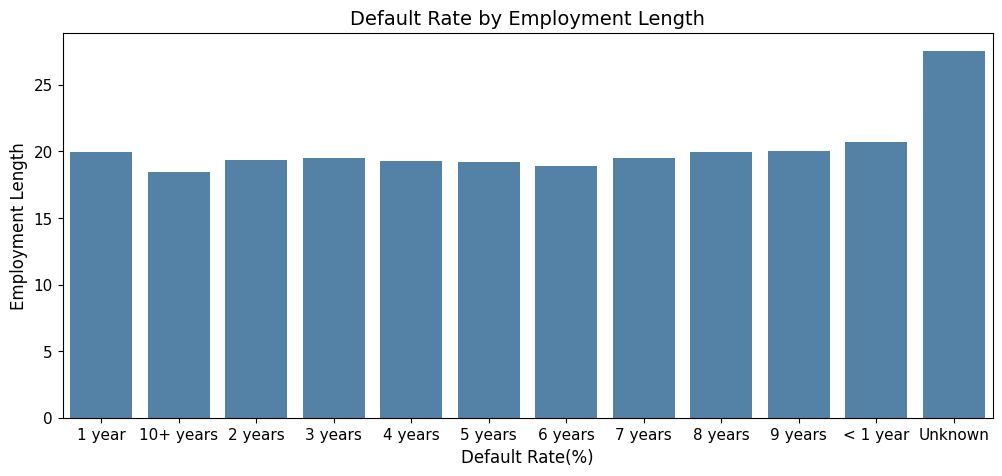

In [41]:
plt.figure(figsize=(12,5))
emp_order=['<1 years','1 years','2 years','3 years','4 years','5 years','6 years','7 years','8 years','9 years','10+ years','Unknown']
sns.barplot(x=emp_default.index, y=emp_default.values, color = "steelblue")
plt.title("Default Rate by Employment Length")
plt.xlabel("Default Rate(%)")
plt.ylabel("Employment Length")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (8,5)
plt.show()

### Insight: 
Borrowers with longer employment histories generally exhibit slightly lower default rates, indicating that employment stability may contribute to improved repayment behavior. However, the impact is less pronounced compared to other financial factors such as interest rate or debt-to-income ratio. Borrowers with unknown employment history show significantly higher default risk.

### Q7️. Which borrower segments contribute the most to portfolio risk?

In [50]:
risk_segment = df.groupby(['income_group','dti_group'])['default_flag'].mean()*100
risk_segment

income_group  dti_group
<40k          0-10         17.991161
              10-20        22.655936
              20-30        26.648468
              30-40        34.868826
              40+          32.038835
40k-80k       0-10         14.226552
              10-20        17.856395
              20-30        23.983829
              30-40        32.003060
              40+          34.228188
80k-120k      0-10         11.695347
              10-20        14.820543
              20-30        20.161330
              30-40        29.507719
              40+          26.315789
120k-200k     0-10         11.100320
              10-20        14.172094
              20-30        18.971178
              30-40        29.066265
              40+          66.666667
200k+         0-10         12.388393
              10-20        14.238411
              20-30        18.631179
              30-40        31.250000
              40+                NaN
Name: default_flag, dtype: float64

In [43]:
risk_table = risk_segment.unstack()
risk_table

dti_group,0-10,10-20,20-30,30-40,40+
income_group,,,,,
<40k,17.991161,22.655936,26.648468,34.868826,31.250000
40k-80k,14.226552,17.856395,23.983829,32.003060,33.774834
80k-120k,11.695347,14.820543,20.161330,29.507719,26.315789
120k-200k,11.100320,14.172094,18.971178,29.066265,66.666667
200k+,12.388393,14.238411,18.631179,31.250000,NaN


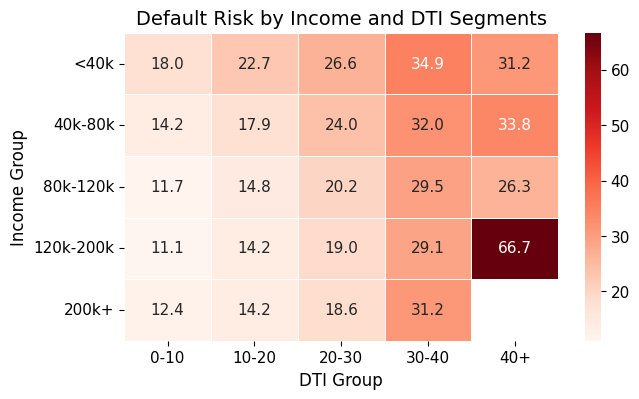

In [44]:
plt.figure(figsize=(7,4))
sns.heatmap(risk_table,annot=True,fmt='.1f',cmap='Reds',linewidths = 0.5)
plt.title('Default Risk by Income and DTI Segments')
plt.xlabel('DTI Group')
plt.ylabel('Income Group')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.figsize'] = (8,5)
plt.show()


### Insight:
Borrowers with lower income and higher debt-to-income ratios exhibit the highest default risk. For example, borrowers earning below $40k with DTI between 30–40 show default rates above 34%, significantly higher than borrowers with higher income and lower debt burdens. This highlights the importance of evaluating repayment capacity when assessing credit risk.

### Statistical Analysis

In [46]:
default_dti = df[df['default_flag']==1]['dti']
non_default_dti = df[df['default_flag']==0]['dti']

In [47]:
t_stat, p_value = ttest_ind(default_dti, non_default_dti)
print("T-statistics:",t_stat)
print("P-value:",p_value)

T-statistics: 39.35383152623921
P-value: 0.0


### Insight:
An independent t-test was conducted to compare the Debt-to-Income ratios between defaulted and fully repaid loans. The results show a statistically significant difference in DTI between the two groups (t = 39.35, p < 0.001), indicating that borrowers who defaulted tend to have significantly higher debt-to-income ratios than those who successfully repaid their loans.

# Financial Impact Analysis

In [48]:
df['loan_amnt'].sum()

np.float64(5589523100.0)

In [49]:
default_loss = df[df['default_flag']==1]['loan_amnt'].sum()
default_loss

np.float64(1174905175.0)

In [50]:
loss_rate = default_loss/df['loan_amnt'].sum()*100
loss_rate

np.float64(21.01977492498421)

### Insight:
The total loan portfolio amounts to approximately $5.59 billion, of which about $1.17 billion corresponds to defaulted loans. This results in a portfolio loss exposure of approximately 21%, indicating that more than one-fifth of the total lending value was associated with charged-off loans.

In [51]:
purpose_loss = df[df['default_flag']==1].groupby('purpose')['loan_amnt'].sum()
purpose_loss.sort_values(ascending=False)

purpose
debt_consolidation    765798400.0
credit_card           214025400.0
home_improvement       64703000.0
other                  48257050.0
small_business         27674225.0
major_purchase         19376775.0
medical                 8987900.0
house                   6550700.0
car                     6291275.0
moving                  5770175.0
vacation                3737700.0
wedding                 2468400.0
renewable_energy         905875.0
educational              358300.0
Name: loan_amnt, dtype: float64

### Insight:
Debt consolidation loans contribute the largest share of total default losses, accounting for approximately USD 765 million, followed by credit card refinancing loans with about USD 214 million in defaulted loan value. Although some loan purposes such as small business exhibit higher default rates, the financial impact is driven primarily by loan categories with the highest lending volume.

# Advanced Analysis

In [52]:
#1. High-Risk Borrower Identification
high_risk = df[
    (df['dti'] > 30) &
    (df['annual_inc'] < 40000)
]

high_risk_summary = {
    'total_loans' : high_risk.shape[0],
    'default_rate (%)': high_risk['default_flag'].mean() * 100,
    'total_exposure': high_risk['loan_amnt'].sum()
}

high_risk_summary

{'total_loans': 7190,
 'default_rate (%)': np.float64(34.92350486787205),
 'total_exposure': np.float64(60771975.0)}

### Insight:
A specific borrower segment characterized by high DTI (>30) and low income (<40K) exhibits a significantly elevated default rate of approximately 35%, compared to the overall portfolio default rate of ~19.6%. Despite representing a smaller portion of the portfolio, this segment accounts for over $60M in exposure, indicating a high-risk group where stricter approval or monitoring strategies could substantially reduce credit losses.

In [51]:
#3. Segment-Level Loss Analysis
segment_loss = df[df['default_flag'] == 1].groupby(
    ['income_group','dti_group']
)['loan_amnt'].sum().reset_index()

segment_loss.sort_values(by='loan_amnt', ascending=False).head(10)

,income_group,dti_group,loan_amnt
7,40k-80k,20-30,238722525.0
6,40k-80k,10-20,224682575.0
11,80k-120k,10-20,122462375.0
12,80k-120k,20-30,89823650.0
8,40k-80k,30-40,79893900.0
2,<40k,20-30,62637900.0
5,40k-80k,0-10,62262625.0
16,120k-200k,10-20,53649850.0
1,<40k,10-20,53482675.0
10,80k-120k,0-10,40083800.0


### Insight:

Top segments:
1. 40K–80K income + 20–30 DTI → ~$238M
   
3. 40K–80K income + 10–20 DTI → ~$224M

   
5. Then mid-income groups follow
   
Default losses are heavily concentrated in mid-income borrowers (40K–80K) with moderate-to-high DTI levels (10–30), contributing the largest share of total financial loss (over $200M per segment). This indicates that while extremely high-risk borrowers exist, the majority of financial impact is driven by high-volume, moderate-risk segments, making them critical targets for risk optimization strategies.

# SQL Analysis Section

In [55]:
conn = sqlite3.connect("lending_club_loan_two.db")

In [56]:
df.to_sql('loan',conn,index=False,if_exists='replace')

396030

### Q1. What is the total number of loans and total portfolio value?

In [57]:
query = """
select count(*) as total_loans,
sum(loan_amnt) as total_portfolio_value
from loan;
"""
pd.read_sql(query,conn)

,total_loans,total_portfolio_value
0,396030,5.589523e+09


### Insight
The platform issued 396,030 loans with a total portfolio value of approximately $5.59B, indicating a large lending portfolio.

### Q2.What percentage of loans defaulted vs fully paid?

In [58]:
query = """
select loan_status,
count(*) as loan_count,
count(*)*100/sum(count(*)) over() as percentage
from loan
group by loan_status;
"""
pd.read_sql(query,conn)

,loan_status,loan_count,percentage
0,Charged Off,77673,19
1,Fully Paid,318357,80


### Insight:
Approximately 19–20% of loans resulted in default, indicating notable credit risk within the portfolio.

### Q3. Which loan purposes have the highest default rates?

In [59]:
query = """
select purpose,
count(*) as total_loans,
sum(CASE WHEN loan_status="Charged Off" THEN 1 ELSE 0 END) as defaulters,
sum(CASE WHEN loan_status="Charged Off" THEN 1 ELSE 0 END)*100/ count(*) as default_rate
from loan
group by purpose
order by default_rate desc;
"""
pd.read_sql(query,conn)

,purpose,total_loans,defaulters,default_rate
0,small_business,5701,1679,29
1,renewable_energy,329,77,23
2,moving,2854,670,23
3,other,21185,4495,21
4,medical,4196,911,21
5,debt_consolidation,234507,48640,20
6,house,2201,434,19
7,vacation,2452,464,18
8,home_improvement,24030,4087,17
9,major_purchase,8790,1448,16


### Insight:
Loan purposes such as small business and moving exhibit the highest default risk, while wedding and car loans show lower default rates.

### Q4. Do lower-income borrowers default more often?

In [60]:
query="""
select 
    CASE 
       WHEN annual_inc < 40000 THEN '<40'
       WHEN annual_inc BETWEEN 40000 AND 80000 THEN '40K-80K'
       WHEN annual_inc BETWEEN 80000 AND 120000 THEN '80K-12K'
       WHEN annual_inc BETWEEN 120000 AND 200000 THEN '120K-200K'
       ELSE '200K+'
       END AS income_group,
       count(*) as total_loans,

       SUM(CASE WHEN loan_status = 'Charged Off' THEN 1 ELSE 0 END)*100/COUNT(*) as default_rate
From loan
group by income_group
order by default_rate DESC;
"""
pd.read_sql(query,conn)

,income_group,total_loans,default_rate
0,<40,74145,24
1,40K-80K,199109,20
2,80K-12K,83393,16
3,120K-200K,32439,14
4,200K+,6878,13
5,200K+,66,13


### Inisght:
Borrowers earning below $40k exhibit the highest default rates, confirming that lower income levels are associated with greater repayment risk.

### Q5. Which loan purposes involve larger average loan amounts?

In [61]:
query = """
select purpose,
avg(loan_amnt) as avg_loan_amount
from loan
group by purpose
order by avg_loan_Amount desc;
"""
pd.read_sql(query,conn)

,purpose,avg_loan_amount
0,house,15395.195366
1,small_business,15387.239081
2,debt_consolidation,14878.519085
3,credit_card,14482.301943
4,home_improvement,14114.051186
5,major_purchase,10928.922071
6,wedding,10231.801876
7,other,9628.554402
8,renewable_energy,9351.823708
9,medical,8954.843899


### Insight:
Loan purposes such as house, small business, and debt consolidation have the highest average loan amounts. This indicates that these categories involve larger financial exposure per loan, increasing potential risk in case of default.

### Q6. Which loan purposes contribute the largest financial losses?

In [62]:
query = """
select purpose,
sum(loan_amnt) as defaulted_amount
from loan
where loan_status = 'Charged Off'
group by purpose
order by defaulted_amount desc;
"""
pd.read_sql(query,conn)

,purpose,defaulted_amount
0,debt_consolidation,765798400.0
1,credit_card,214025400.0
2,home_improvement,64703000.0
3,other,48257050.0
4,small_business,27674225.0
5,major_purchase,19376775.0
6,medical,8987900.0
7,house,6550700.0
8,car,6291275.0
9,moving,5770175.0


### Insight:
Debt consolidation and credit card loans contribute the highest total financial losses due to their large loan volumes. While some categories may have higher default rates, the overall financial impact is driven by high-volume loan segments.

### SQL Analysis Summary:
The SQL queries above were used to validate key portfolio metrics and borrower risk patterns directly from the database. These queries replicate several insights observed during the Python-based analysis, including overall default rates, risk distribution across income segments, and loan purpose–level default behavior. SQL allows analysts to quickly compute these metrics on production databases without relying on external analytical tools.

### Key SQL Insights:

1.The loan portfolio contains 396k loans with a total value of ~$5.6B.

2.Approximately 20% of loans defaulted, indicating substantial credit risk.

3.Debt consolidation and credit card loans contribute the largest share of default losses.

4.Lower-income borrowers show significantly higher default rates.

# Key Findings
1. The lending portfolio totals approximately USD 5.6, with a default rate of 19.6% , resulting in an estimated USD 1.17B in financial loss (~21% expposure).
2. Borrowers with high debt-to-income ratios (DTI>30) and low annual income (<40K) exhibit significantlly higher default rates (~35%), making them a high-risk segment.
3. Default losses are heavily concentrated in mid-income borrowers (40k-80k) with moderate-to-high DTI levels (10-30), contributing over ~$200M per segment, driven by high loan volume.
4. Loan purpose analysis shows that debt consolidation loans contribute the highest financial losses, even if not always the highest-risk category.
5. Higher interest rate loans show increased default rates, indicating that risk-based pricing reflects borrower risk but also exposes lenders to higher loss potential.
6. Statistical testing confirms a significant difference between defaulted and non-defaulted borrowers, validating the importance of borrower characteristics in predicting credit risk.

### Credit Risk Decision Summary

Based on the analysis:

1. High-risk borrowers are those with DTI >30 and income <40K, showing default rates above 30%.
2. Medium-risk borrowers fall in the DTI 20–30 range, with moderate default risk.
3. Low-risk borrowers have DTI below 20, with relatively low default rates.

# Business Recommendations
1. Implement stricter evaluation and monitoring for high DTI (>30) and low-income (<40K) borrowers, as they represent the highest-risk segment.
2. Prioritize risk optimization in mid-income segments (40K–80K), as they contribute the largest share of financial losses due to high loan volumes.
3. Refine credit policies for debt consolidation loans, including better screening or adjusted loan terms to reduce loss exposure.
4. Use interest rate segmentation not only for pricing risk but also for identifying high-risk borrowers requiring additional verification or controls.
5. Introduce risk-based approval strategies, where moderate-risk borrowers are managed carefully to balance growth and risk.
6. Strengthen credit assessment using key borrower indicators such as DTI, income, and loan purpose to improve loan quality.
7. Even a 10% reduction in defaults can save ~$117M, making credit risk optimization a high-impact financial strategy.

### Transition to dashboard:  To communicate these findings more effectively to business stakeholders, the next step is to develop an interactive Power BI dashboard highlighting portfolio performance, borrower risk segments, and financial loss exposure.

In [65]:
df.to_csv("cleann_lending_data.csv",index=False)